# Bandido de k-brazos — Softmax

*Descripción:* Estudio comparativo de configuraciones del algoritmo Softmax en el problema del bandido de k-brazos. Se generan gráficas de recompensas promedio para cada algoritmo.

En este notebook se utilizarán 3 temperaturas
- T = 0.1
- T = 0.5
- T = 1.0


In [1]:
import sys
sys.path.append('/content/eml_k_bandit')

import numpy as np
from src.algorithms import Softmax
from src.arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from src.bandit_experiment import BanditExperiment

SEED = 42
np.random.seed(SEED)

## Experimento

In [2]:
k = 10; steps = 1000; runs = 500; n = 10
NORMAL_NAME = "normal" ; BERNOULLI_NAME = "bernoulli" ; BINOMIAL_NAME = "binomial"
algorithms = [Softmax(k=k, temperature=temperature) for temperature in [0.1, 0.5, 1.0]]

bandits = {
    NORMAL_NAME: Bandit(arms=ArmNormal.generate_arms(k)),
    BERNOULLI_NAME: Bandit(arms=ArmBernoulli.generate_arms(k)),
    BINOMIAL_NAME: Bandit(arms=ArmBinomial.generate_arms(k, n=n))
}

results = {name: BanditExperiment.run_experiment(bandit, algorithms, steps, runs) for name, bandit in bandits.items()}

## Ejecución del experimento

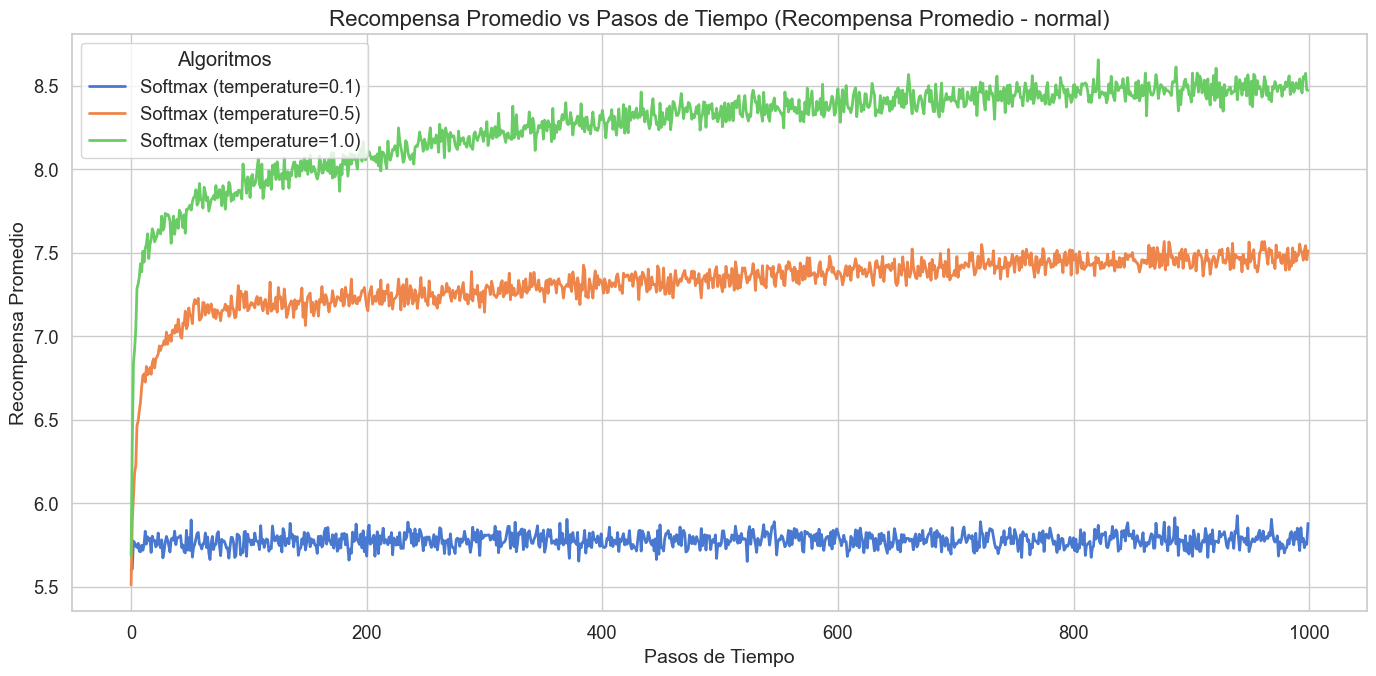

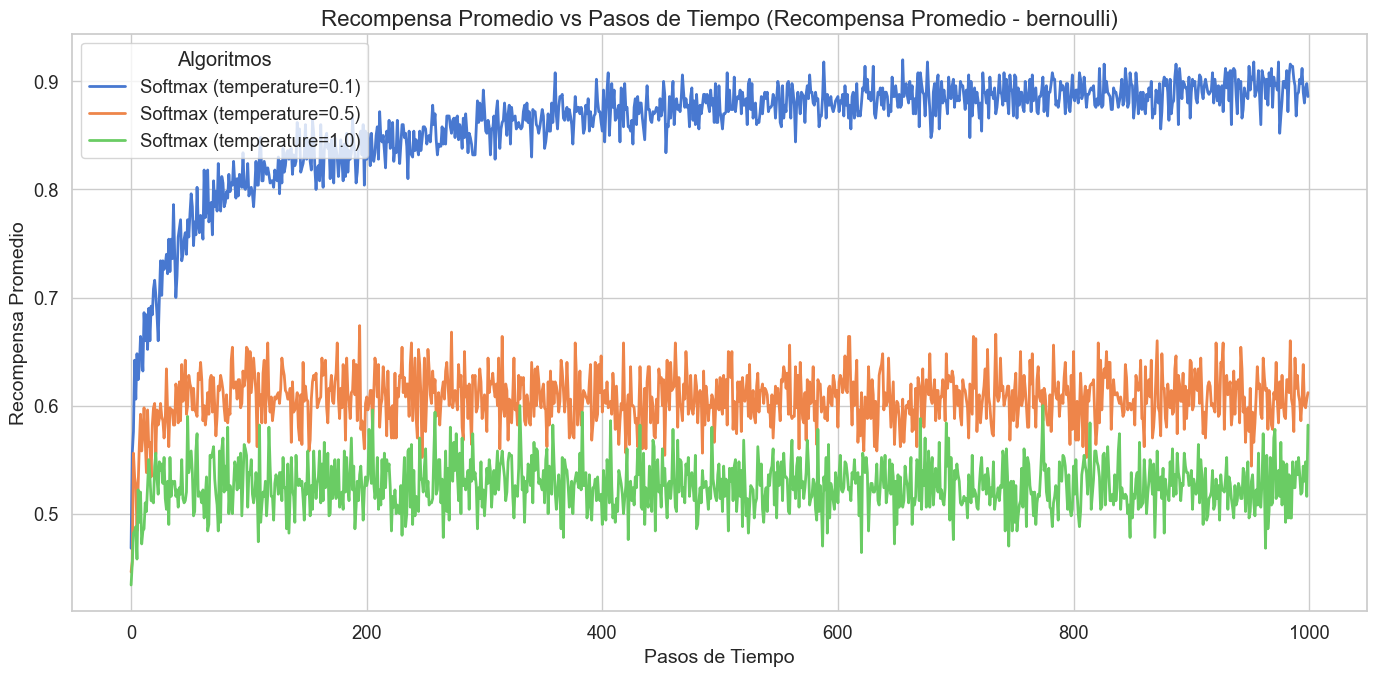

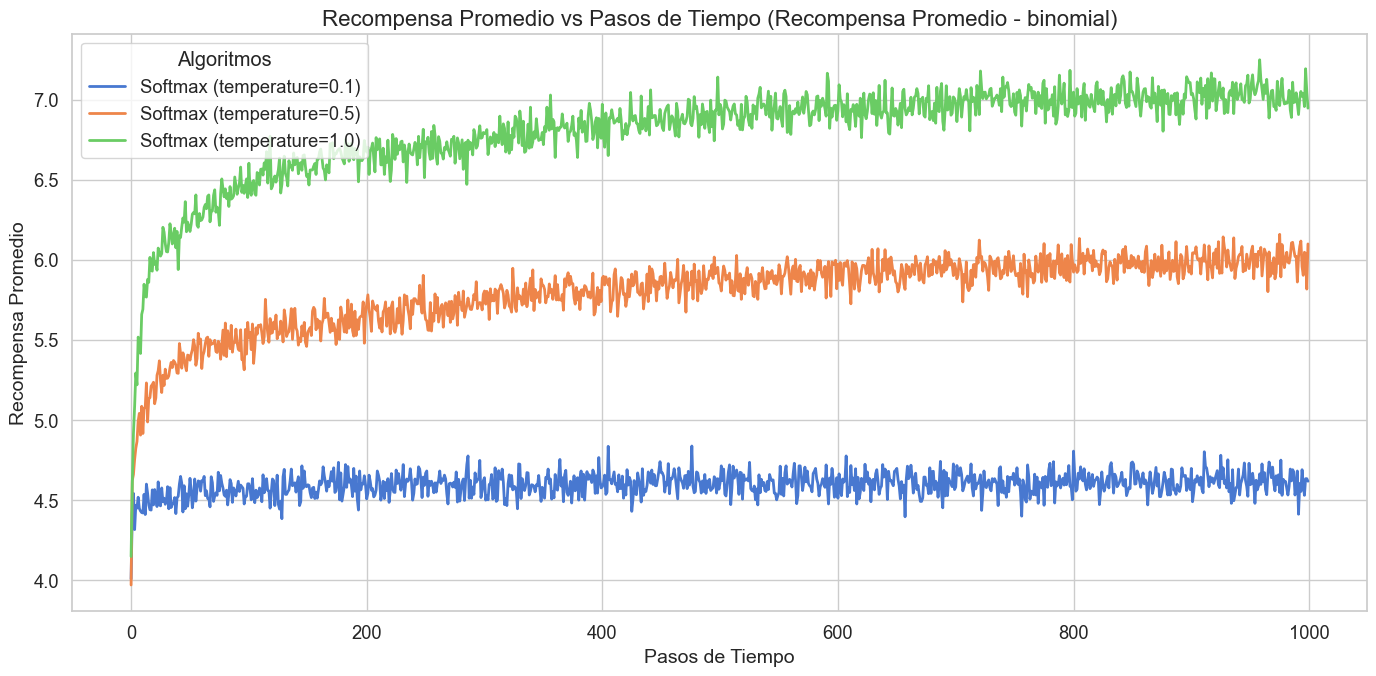

In [3]:
BanditExperiment.plot_rewards(results, steps, algorithms)

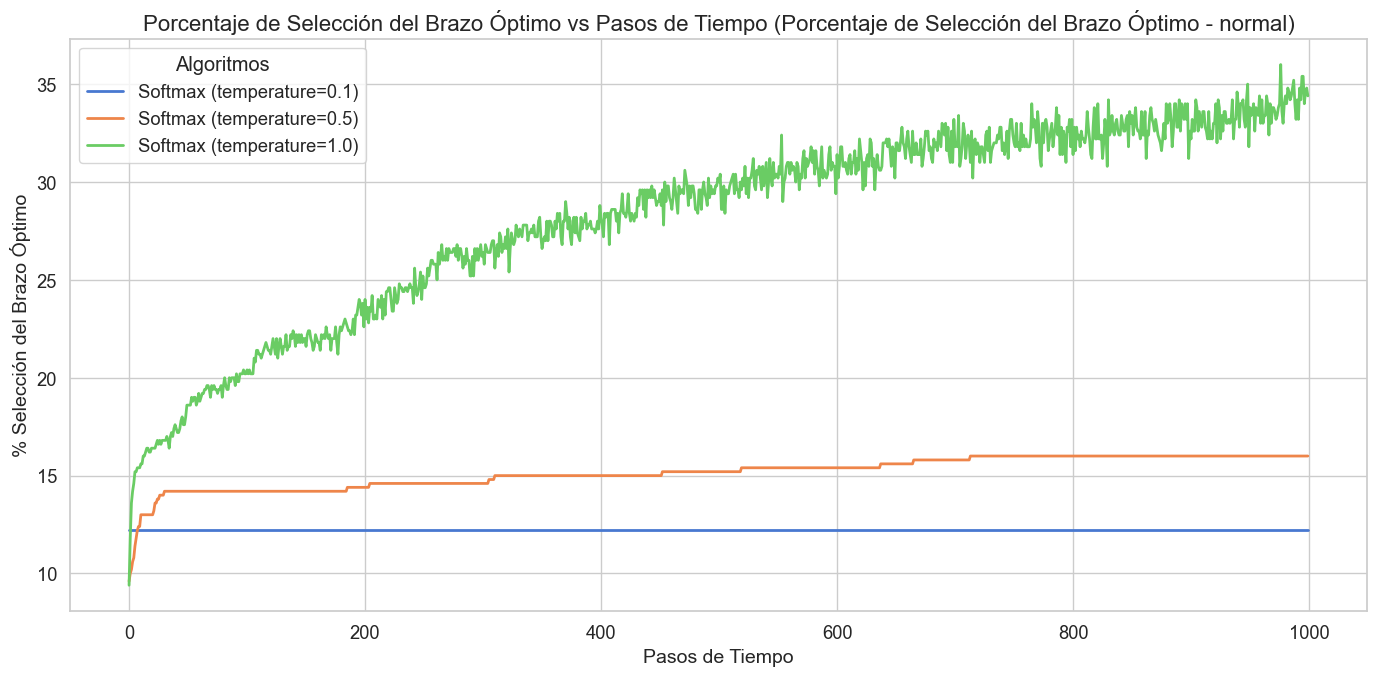

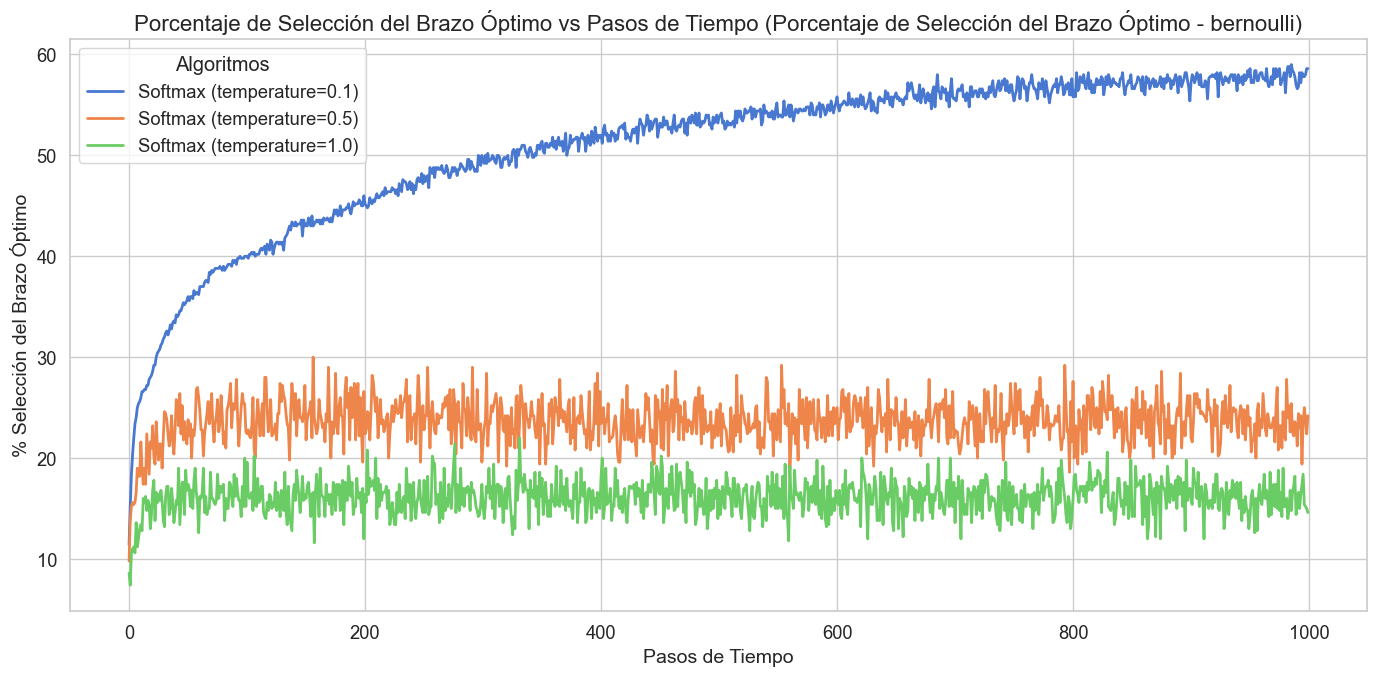

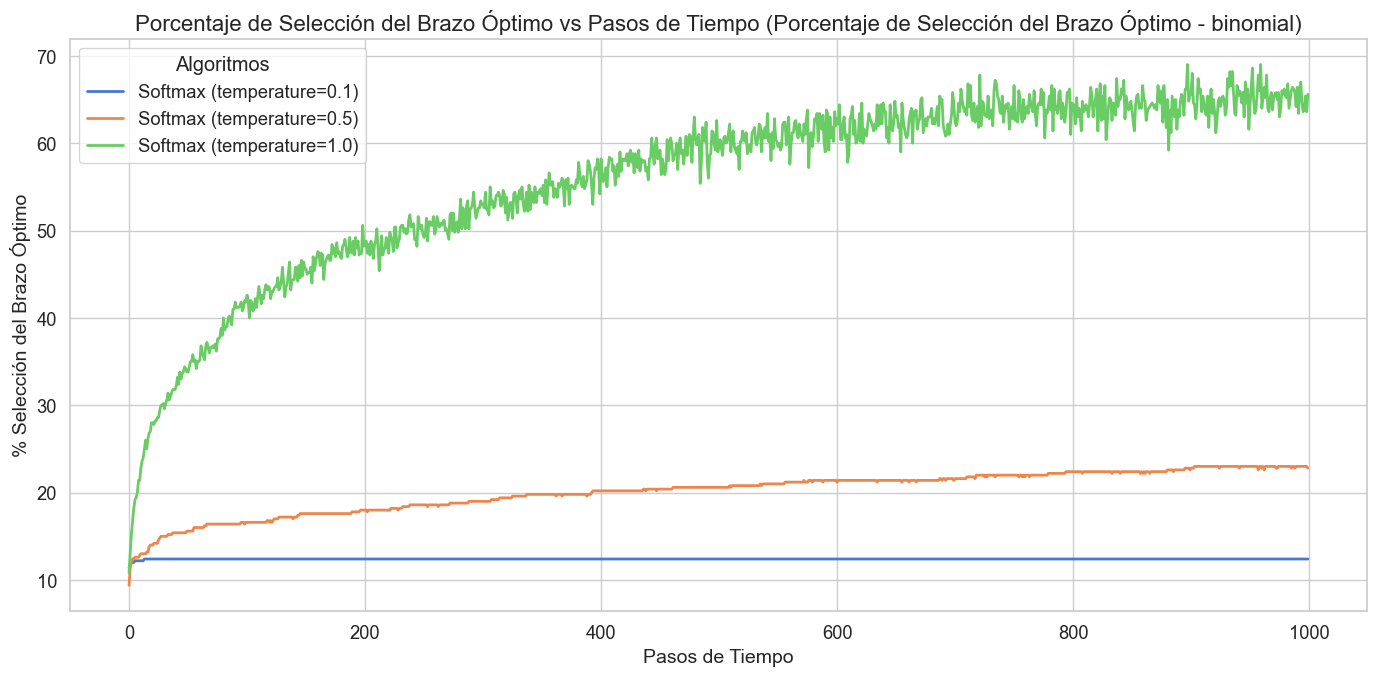

In [4]:
BanditExperiment.plot_optimal_selections(results, steps, algorithms)

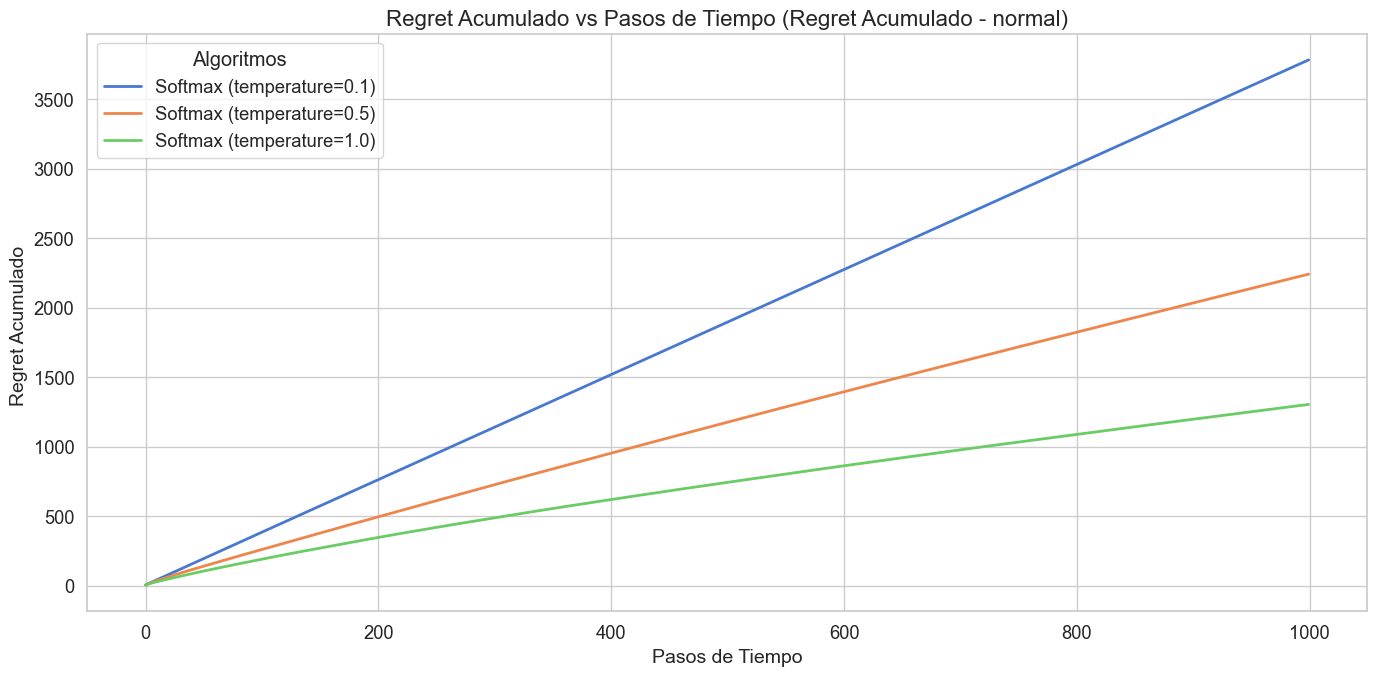

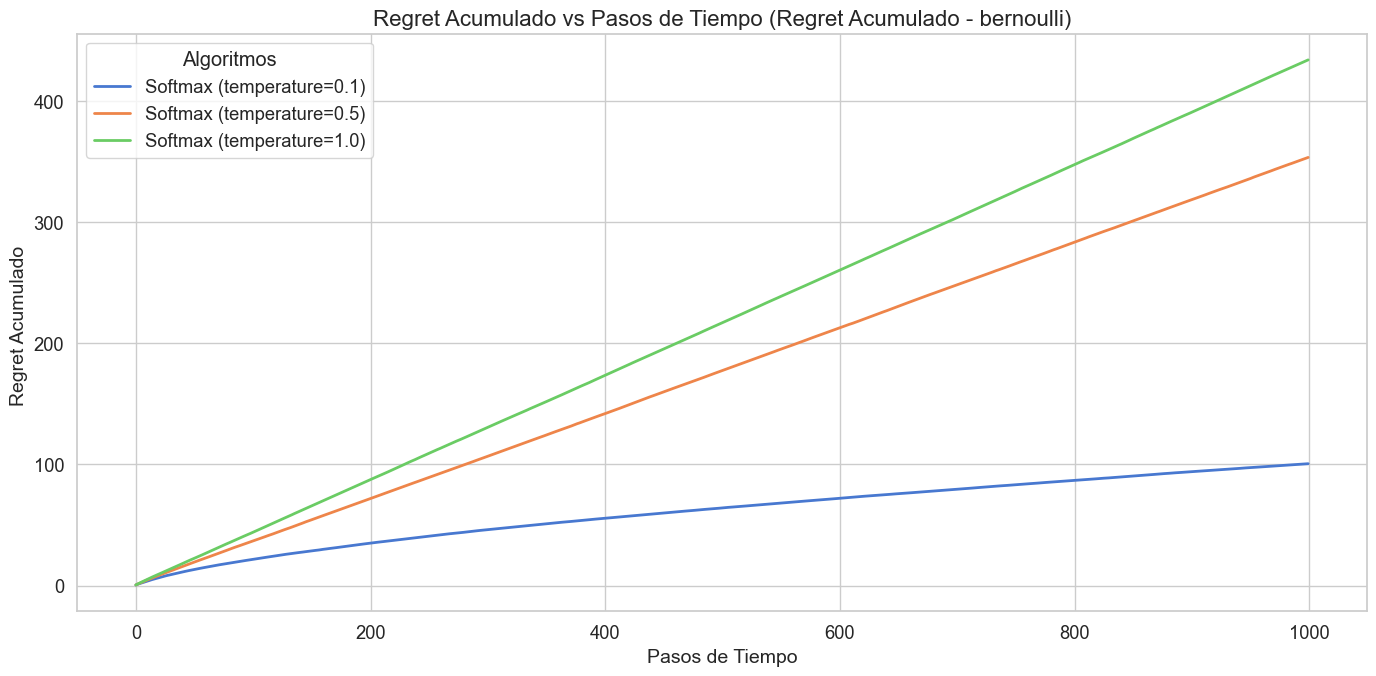

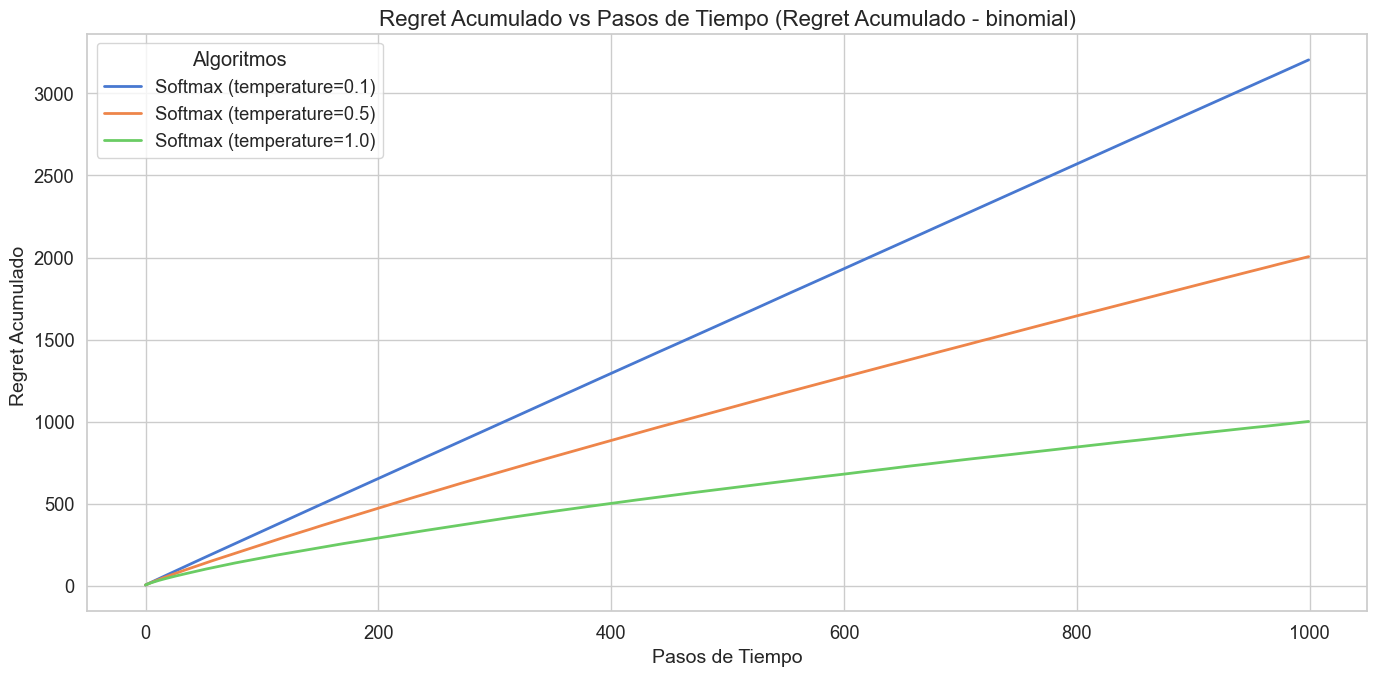

In [5]:
BanditExperiment.plot_regrets(results, steps, algorithms)

<Figure size 1400x700 with 0 Axes>

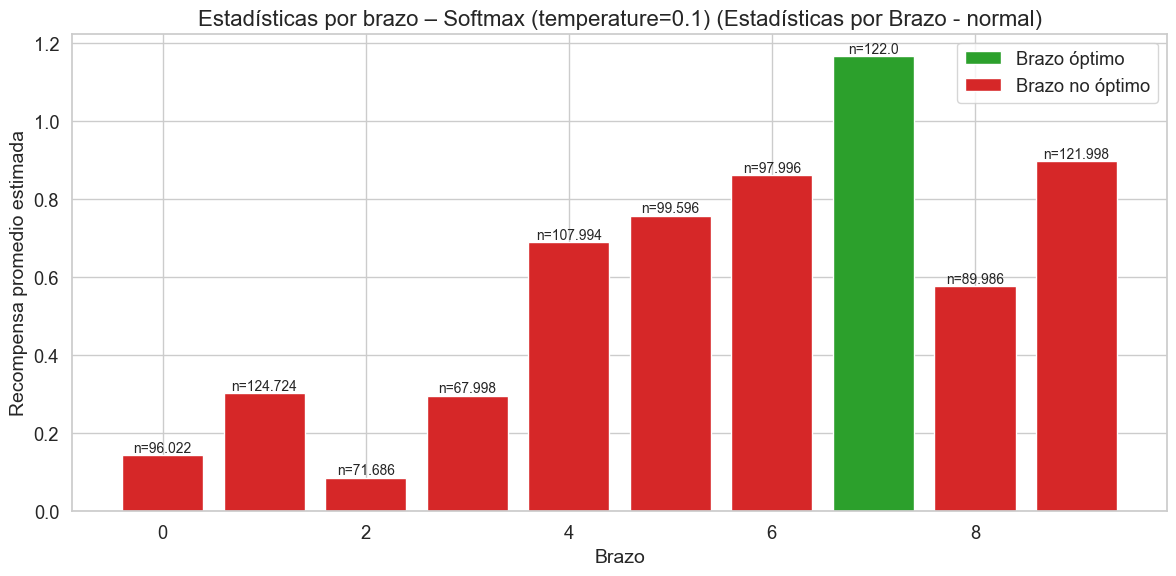

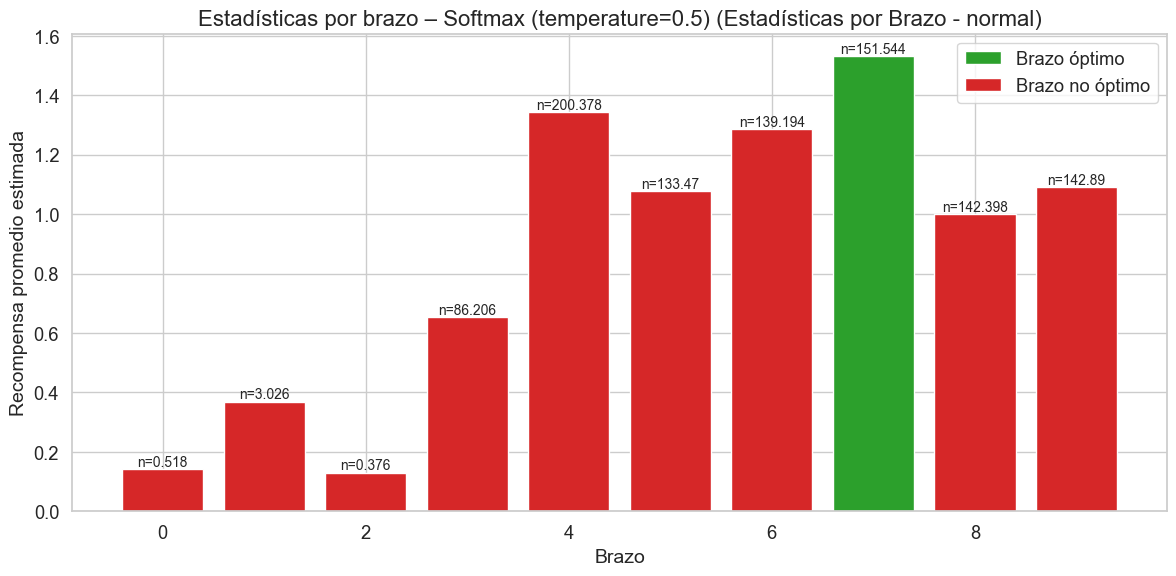

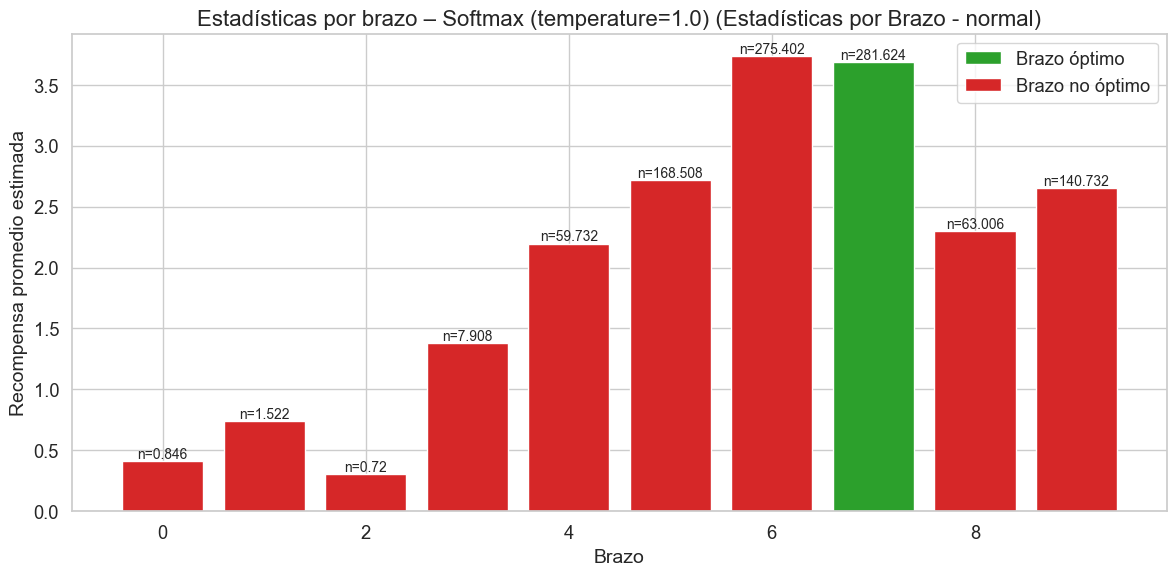

<Figure size 1400x700 with 0 Axes>

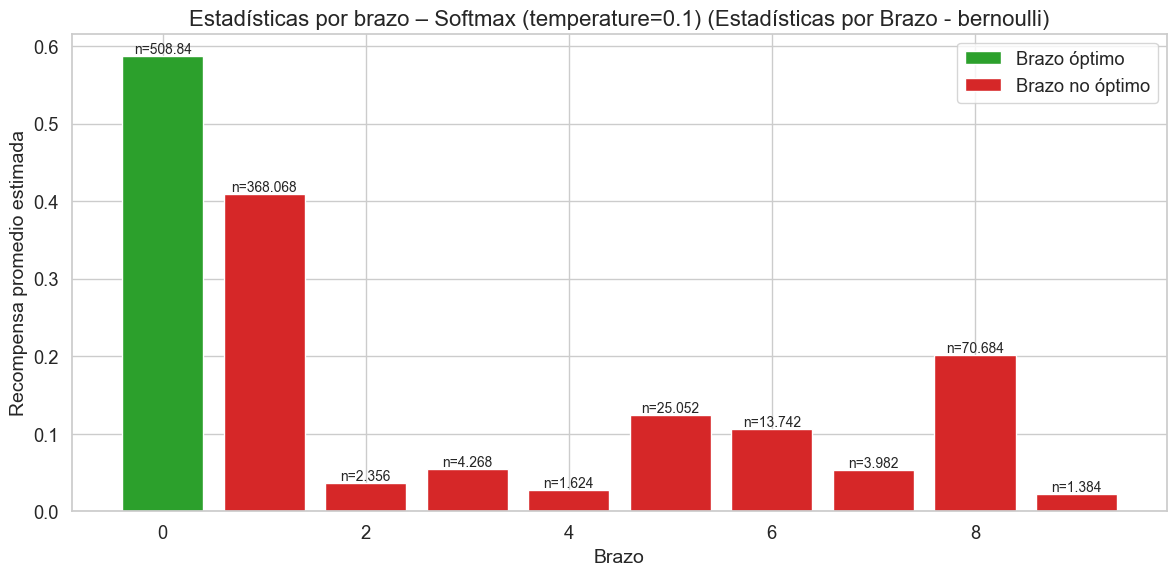

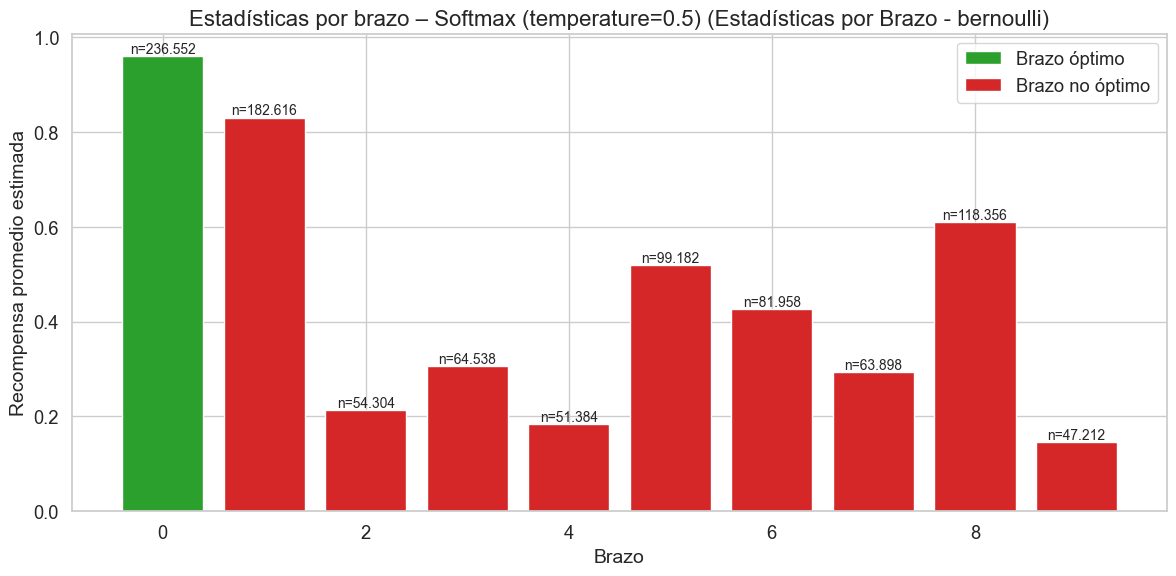

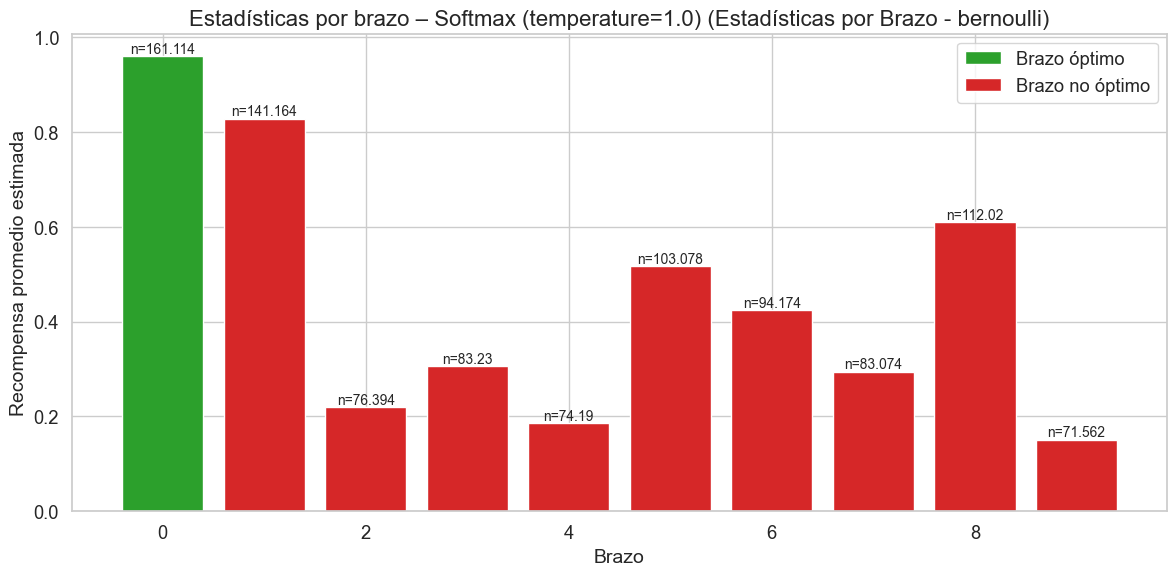

<Figure size 1400x700 with 0 Axes>

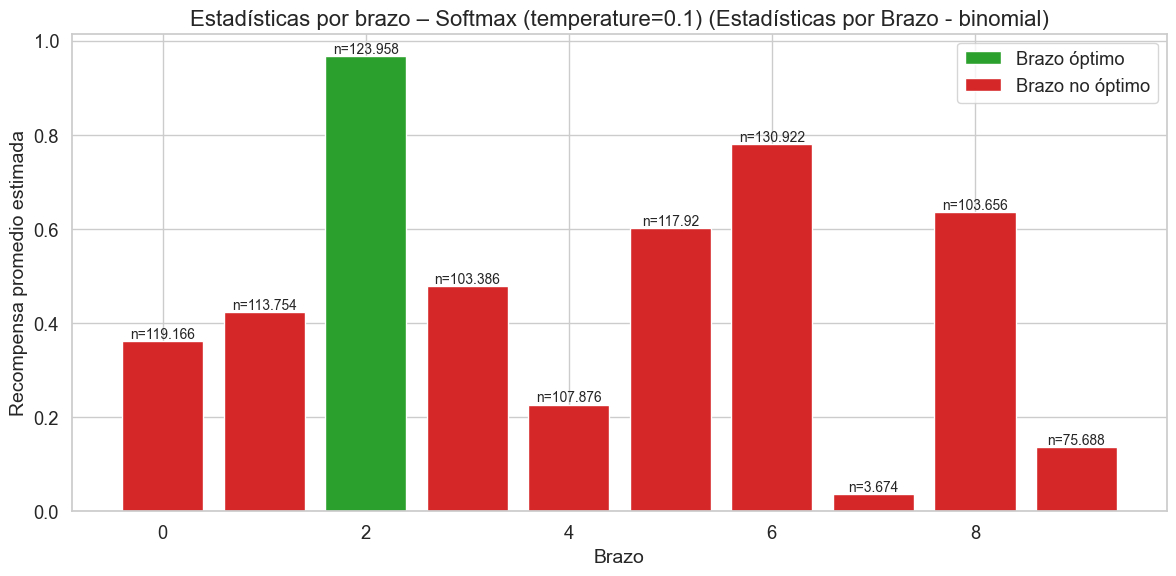

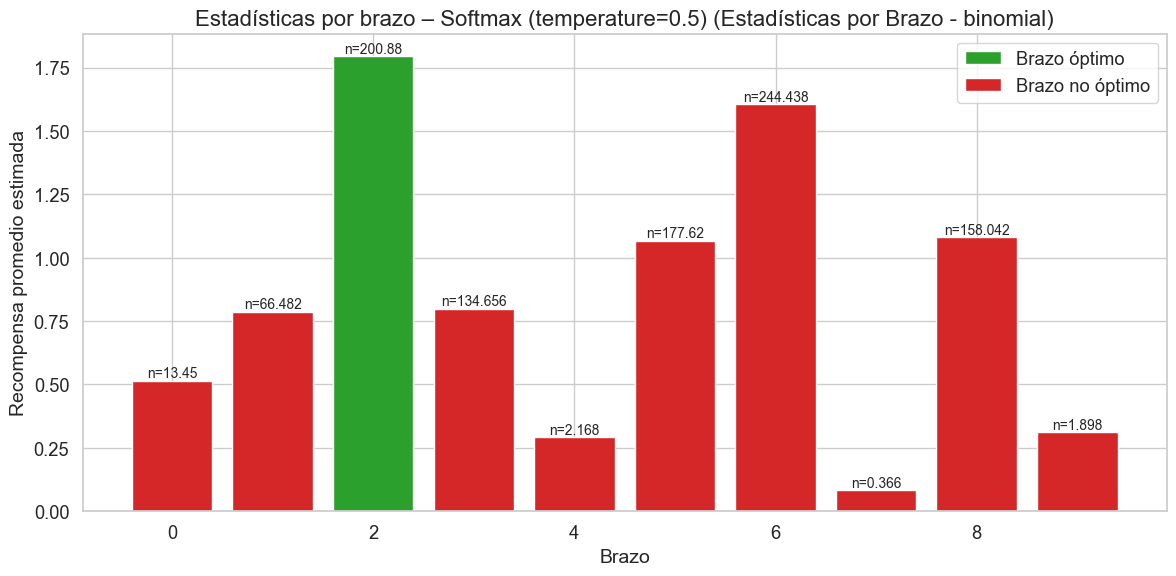

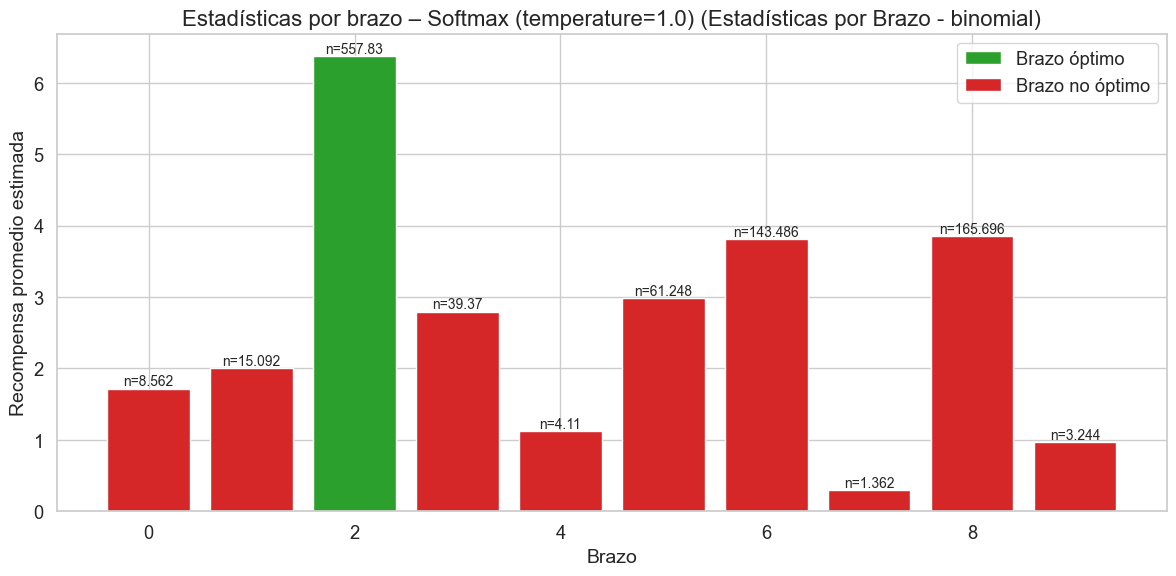

In [6]:
for name in [NORMAL_NAME,BERNOULLI_NAME,BINOMIAL_NAME]:
    BanditExperiment.plot_arm_statistics(bandits[name], results[name], algorithms, name)